<a href="https://colab.research.google.com/github/Harish2859/Learning-Supervised-Classification-Titanic/blob/main/Diabetes_Clinical_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('diabetes.csv')


X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


train_data = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_data = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

print(f"Ready! We have {len(train_loader)} batches per epoch.")

Ready! We have 20 batches per epoch.


In [13]:
import torch.nn as nn
import torch.optim as optim

class ClinicalNet(nn.Module):
    def __init__(self):
        super(ClinicalNet, self).__init__()

        self.fc1 = nn.Linear(8, 16)
        self.relu = nn.ReLU()


        self.dropout = nn.Dropout(p=0.5)


        self.fc2 = nn.Linear(16, 8)


        self.fc3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


model = ClinicalNet()


optimizer = optim.Adam(model.parameters(), lr=0.001)


criterion = nn.BCELoss()

print("Model Architecture & Adam Optimizer are initialized.")

Model Architecture & Adam Optimizer are initialized.


In [14]:
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(sum(batch_losses)/len(batch_losses))


    model.eval()
    with torch.no_grad():
        v_batch_losses = []
        for v_inputs, v_labels in val_loader:
            v_outputs = model(v_inputs)
            v_loss = criterion(v_outputs.squeeze(), v_labels)
            v_batch_losses.append(v_loss.item())
        val_losses.append(sum(v_batch_losses)/len(v_batch_losses))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\nTrial Complete!")

Epoch 10/50 | Train Loss: 0.5477 | Val Loss: 0.5435
Epoch 20/50 | Train Loss: 0.4796 | Val Loss: 0.5045
Epoch 30/50 | Train Loss: 0.4967 | Val Loss: 0.5084
Epoch 40/50 | Train Loss: 0.4702 | Val Loss: 0.5066
Epoch 50/50 | Train Loss: 0.4559 | Val Loss: 0.5104

Trial Complete!


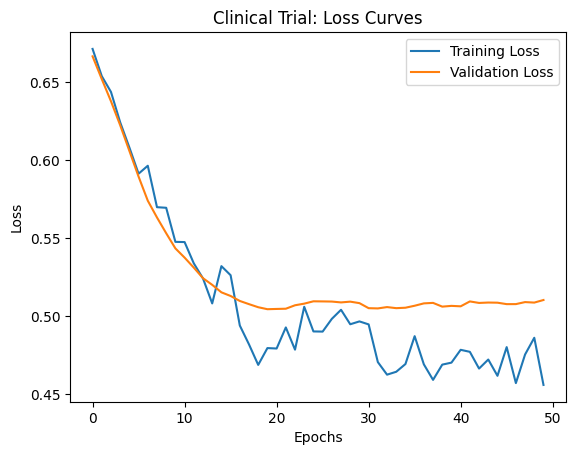

In [15]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Clinical Trial: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()